**4: Model Building and Comparing Regressors**

ML Regression Model Building and Comparison.

Code adapted from https://github.com/dataprofessor.

In [ ]:
! pip install scikit-learn
! pip install lazypredict

## **1. Import libraries**

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor

## **2. Load the data set**


In [4]:
df = pd.read_csv('acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [5]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

## **3. Data pre-processing**

In [6]:
# Examine X dimension
X.shape

(6641, 881)

In [7]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))    
X = selection.fit_transform(X)
X.shape

(6641, 146)

In [8]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## **4. Compare ML algorithms**

In [9]:
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


In [10]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
models_train,predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test,predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

  0%|          | 0/42 [00:00<?, ?it/s]

100%|██████████| 42/42 [01:57<00:00,  2.80s/it]


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001462 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 5312, number of used features: 146
[LightGBM] [Info] Start training from score 5.812101
'tuple' object has no attribute '__name__'
Invalid Regressor(s)


100%|██████████| 42/42 [01:50<00:00,  2.64s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 5312, number of used features: 146
[LightGBM] [Info] Start training from score 5.812101


In [11]:
# Performance table of the training set (80% subset)
predictions_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
GaussianProcessRegressor,0.94,0.94,0.37,7.90
ExtraTreeRegressor,0.94,0.94,0.37,0.15
ExtraTreesRegressor,0.94,0.94,0.37,8.59
DecisionTreeRegressor,0.94,0.94,0.37,0.15
RandomForestRegressor,0.92,0.92,0.45,6.57
BaggingRegressor,0.90,0.90,0.48,0.82
XGBRegressor,0.90,0.90,0.48,0.21
MLPRegressor,0.90,0.90,0.49,12.45
HistGradientBoostingRegressor,0.76,0.77,0.75,1.05


In [12]:
# Performance table of the test set (20% subset)
predictions_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
RandomForestRegressor,0.66,0.70,0.85,6.33
XGBRegressor,0.66,0.70,0.85,0.23
BaggingRegressor,0.63,0.67,0.89,0.68
HistGradientBoostingRegressor,0.61,0.66,0.91,0.63
LGBMRegressor,0.60,0.65,0.92,0.18
MLPRegressor,0.59,0.64,0.93,12.01
KNeighborsRegressor,0.57,0.62,0.96,0.07
SVR,0.57,0.61,0.96,2.52
NuSVR,0.56,0.61,0.97,1.88


## **5. Data visualization of model performance**

Text(0.5, 1.0, 'Comparison of Model Performance (R-Squared)')

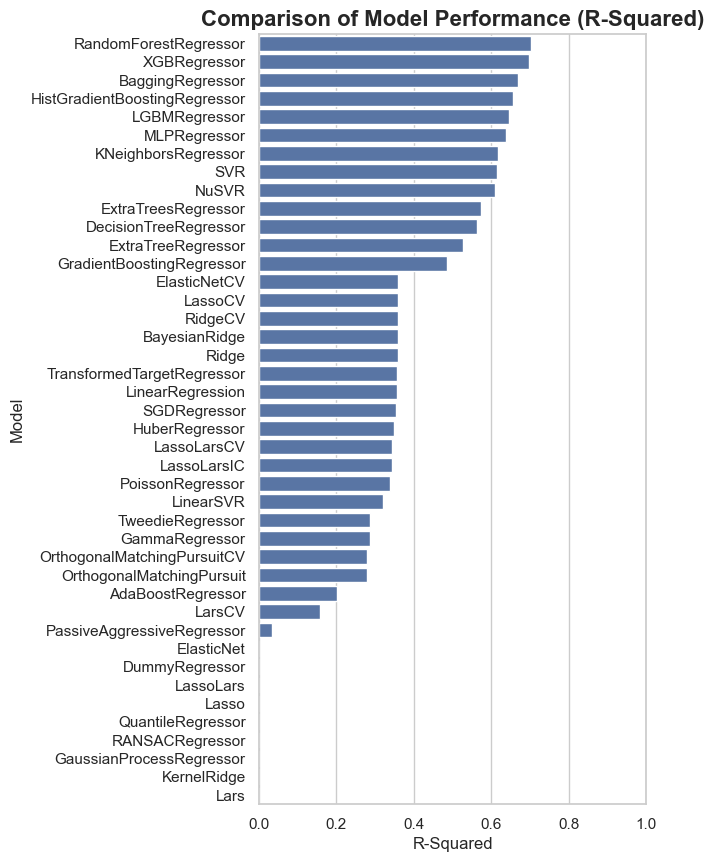

In [17]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_test.index, x="R-Squared", data=predictions_test)
ax.set(xlim=(0, 1))
# Add title
plt.title('Comparison of Model Performance (R-Squared)', fontsize=16, fontweight='bold')

Text(0.5, 1.0, 'Comparison of Model Performance (RMSE)')

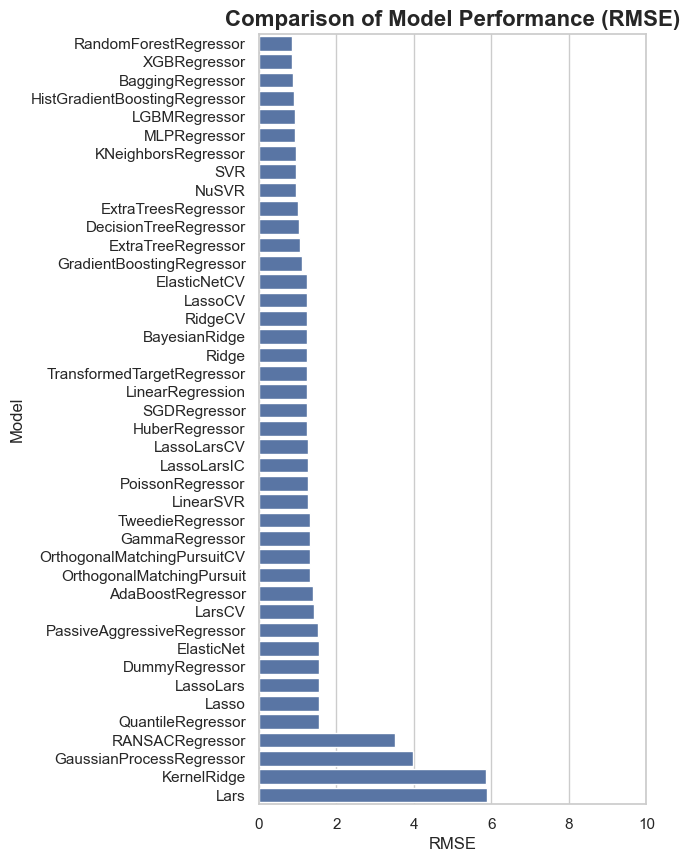

In [16]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_test.index, x="RMSE", data=predictions_test)
ax.set(xlim=(0, 10))
plt.title('Comparison of Model Performance (RMSE)', fontsize=16, fontweight='bold')


Text(0, 0.5, 'Model')

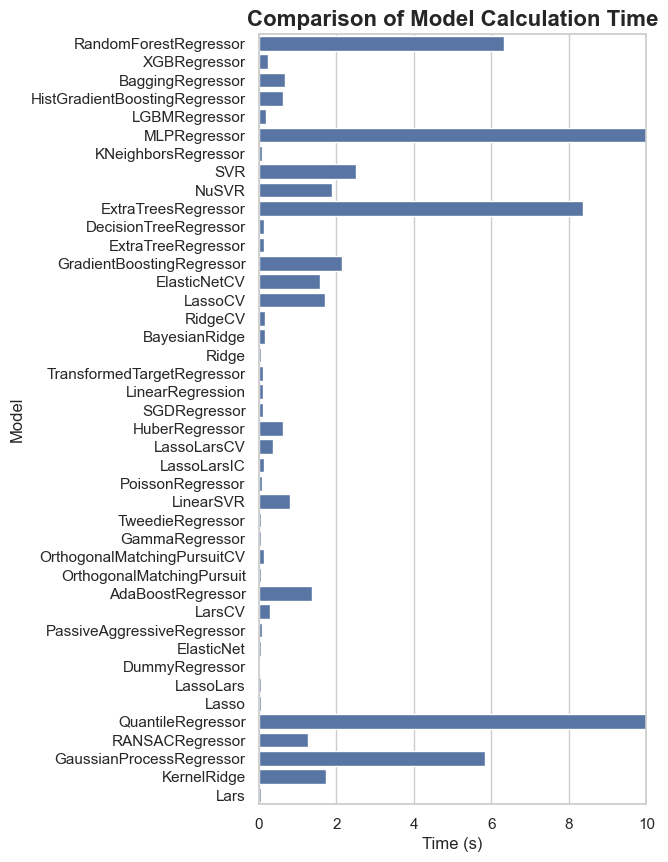

In [15]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_test.index, x="Time Taken", data=predictions_test)
ax.set(xlim=(0, 10))
plt.title('Comparison of Model Calculation Time', fontsize=16, fontweight='bold')
plt.xlabel("Time (s)")       
plt.ylabel("Model")  


# XGBRegressor Model Building 

In [ ]:
! pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

In [30]:
# Initialize the XGBRegressor
xgb_model = XGBRegressor(random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, Y_train)

# Make predictions on test set
y_test_pred = xgb_model.predict(X_test)

# Evaluate performance on the test set
r2_test = r2_score(Y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y_test, y_test_pred))

print(f"Test R-Squared: {r2_test:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

Test R-Squared: 0.70
Test RMSE: 0.85


# Data Visualization (Experimental vs Predicted pIC50 for Training Data)

In [31]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0, 'Experimental pIC50')

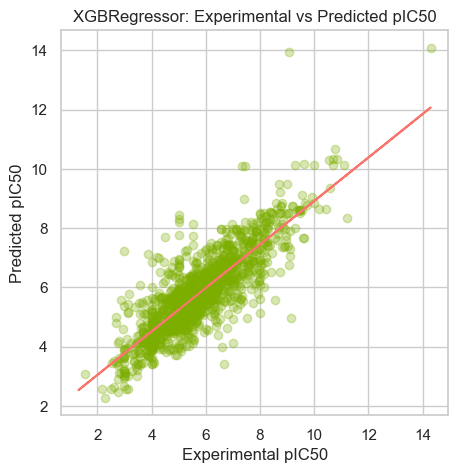

In [34]:
plt.figure(figsize=(5,5))
plt.scatter(x=Y_test, y=y_test_pred, c="#7CAE00", alpha=0.3)

# Add trendline
# https://stackoverflow.com/questions/26447191/how-to-add-trendline-in-python-matplotlib-dot-scatter-graphs
z = np.polyfit(Y_test, y_test_pred, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.title('XGBRegressor: Experimental vs Predicted pIC50')
plt.ylabel('Predicted pIC50')
plt.xlabel('Experimental pIC50')

# Save Model as Pickle Object

In [35]:
import pickle

In [36]:
pickle.dump(xgb_model, open('acetylcholinesterase_model.pkl', 'wb'))